In [47]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stocks = ["AAPL", "MSFT", "GOOGL"]

data = yf.download(
    stocks,
    start="2025-04-30",
    end="2026-04-30"
)

print(data.head())

[*********************100%***********************]  3 of 3 completed

Price            Close                                High              \
Ticker            AAPL       GOOGL        MSFT        AAPL       GOOGL   
Date                                                                     
2025-04-30  211.383118  158.251266  391.409302  212.457443  158.719644   
2025-05-01  212.198792  160.742645  421.255646  213.432264  161.390393   
2025-05-02  204.270691  163.463211  431.039398  205.902071  164.399965   
2025-05-05  197.844635  163.642578  431.920746  203.027258  164.818493   
2025-05-06  197.466629  162.665970  429.088593  199.595381  164.230552   

Price                          Low                                Open  \
Ticker            MSFT        AAPL       GOOGL        MSFT        AAPL   
Date                                                                     
2025-04-30  392.795657  205.583758  154.863006  380.694705  208.199940   
2025-05-01  432.732730  207.802010  158.360904  420.760517  207.981072   
2025-05-02  435.158874  201.097455  1

In [48]:
close_prices = data["Close"]

print(close_prices.head())

Ticker            AAPL       GOOGL        MSFT
Date                                          
2025-04-30  211.383118  158.251266  391.409302
2025-05-01  212.198792  160.742645  421.255646
2025-05-02  204.270691  163.463211  431.039398
2025-05-05  197.844635  163.642578  431.920746
2025-05-06  197.466629  162.665970  429.088593


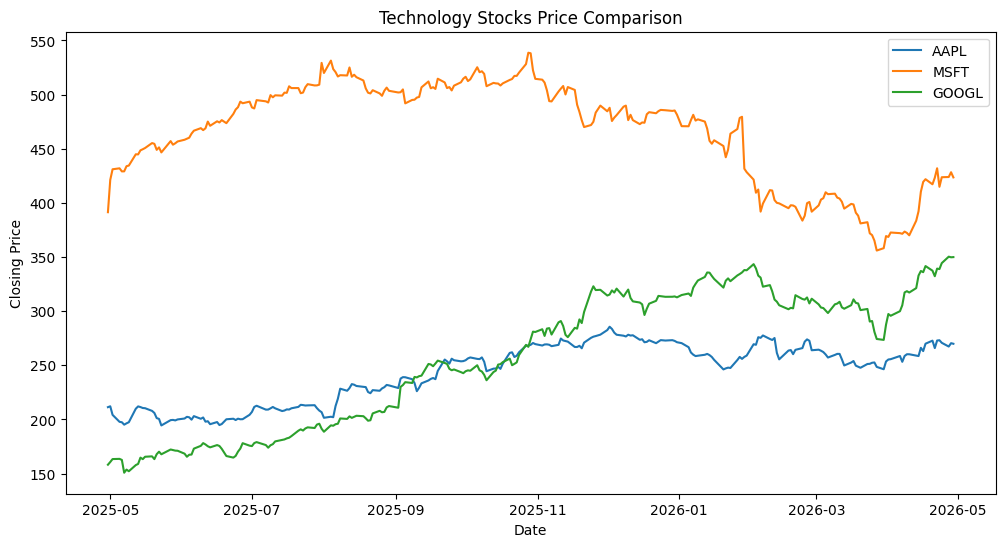

In [49]:
plt.figure(figsize=(12,6))

for stock in stocks:
    plt.plot(close_prices.index, close_prices[stock], label=stock)

plt.title("Technology Stocks Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [50]:
daily_returns = close_prices.pct_change()

print(daily_returns.head())

Ticker          AAPL     GOOGL      MSFT
Date                                    
2025-04-30       NaN       NaN       NaN
2025-05-01  0.003859  0.015743  0.076254
2025-05-02 -0.037362  0.016925  0.023225
2025-05-05 -0.031459  0.001097  0.002045
2025-05-06 -0.001911 -0.005968 -0.006557


In [51]:
volatility = daily_returns.rolling(window=10).std()

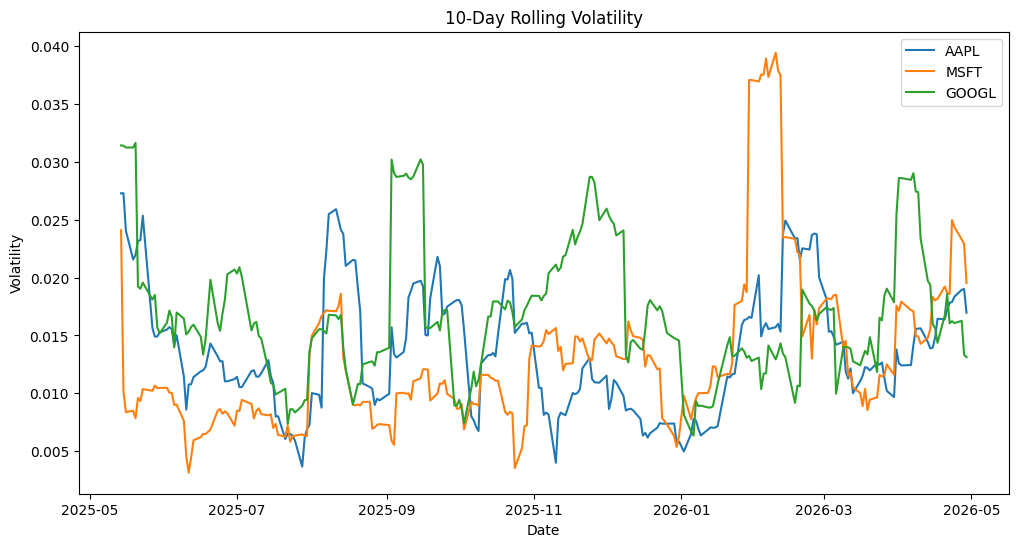

In [52]:
plt.figure(figsize=(12,6))

for stock in stocks:
    plt.plot(volatility.index, volatility[stock], label=stock)

plt.title("10-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()

plt.show()

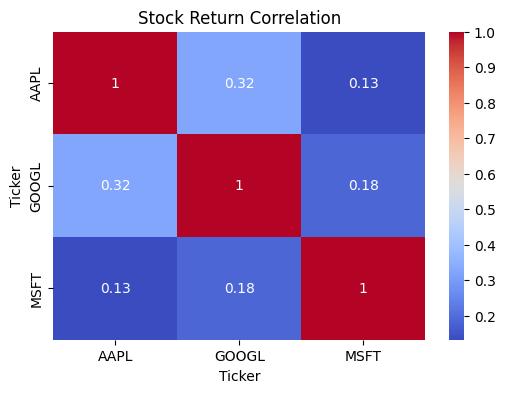

In [53]:
correlation = daily_returns.corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Stock Return Correlation")

plt.show()

In [54]:
msft = close_prices["MSFT"]

In [55]:
ma10 = msft.rolling(window=10).mean()

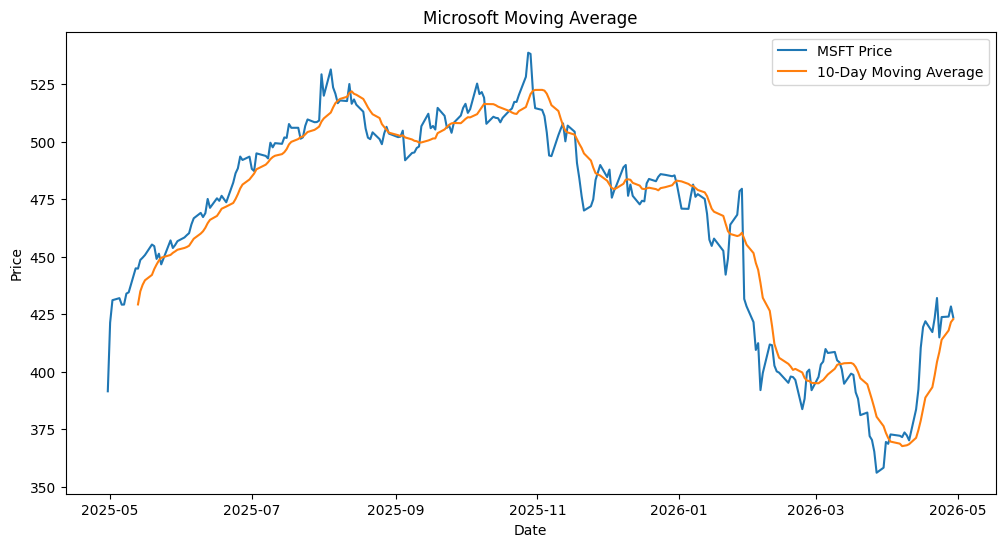

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
    msft.index,
    msft,
    label="MSFT Price"
)

plt.plot(
    ma10.index,
    ma10,
    label="10-Day Moving Average"
)

plt.title("Microsoft Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [57]:
import pandas as pd

signals = pd.DataFrame(index=msft.index)

signals["price"] = msft

signals["ma10"] = ma10

signals["signal"] = 0

signals.loc[
    signals["price"] > signals["ma10"],
    "signal"
] = 1

signals["position"] = signals["signal"].diff()

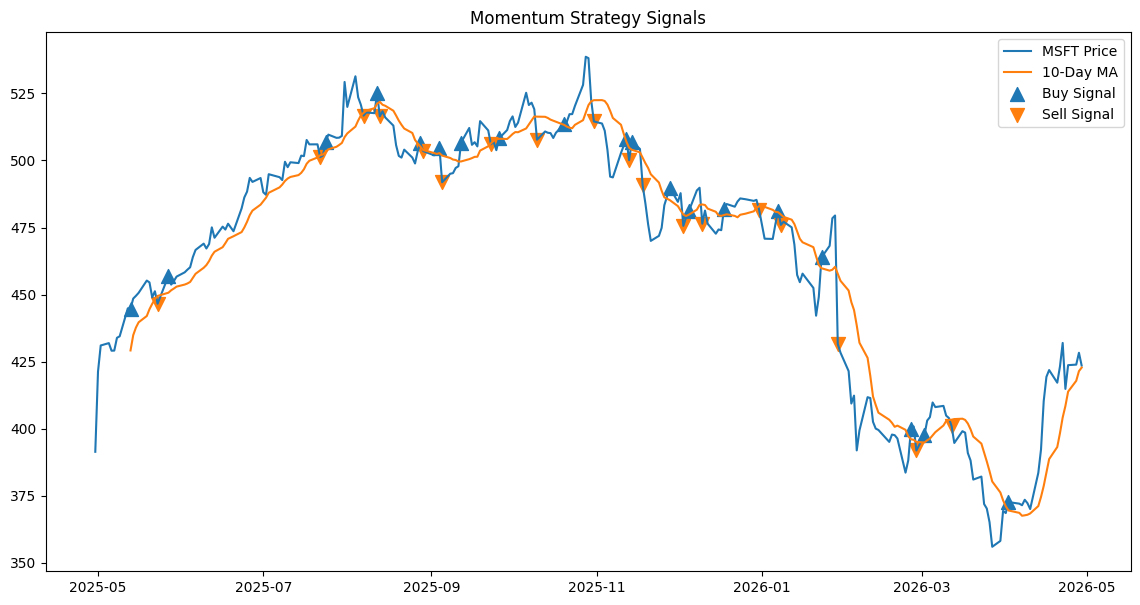

In [58]:
plt.figure(figsize=(14,7))

plt.plot(
    signals.index,
    signals["price"],
    label="MSFT Price"
)

plt.plot(
    signals.index,
    signals["ma10"],
    label="10-Day MA"
)

buy_signals = signals[
    signals["position"] == 1
]

sell_signals = signals[
    signals["position"] == -1
]

plt.scatter(
    buy_signals.index,
    buy_signals["price"],
    marker="^",
    s=100,
    label="Buy Signal"
)

plt.scatter(
    sell_signals.index,
    sell_signals["price"],
    marker="v",
    s=100,
    label="Sell Signal"
)

plt.title("Momentum Strategy Signals")

plt.legend()

plt.show()

In [59]:
strategy_returns = (
    daily_returns["MSFT"] *
    signals["signal"].shift(1)
)

In [60]:
cumulative_market = (
    1 + daily_returns["MSFT"]
).cumprod()

cumulative_strategy = (
    1 + strategy_returns
).cumprod()

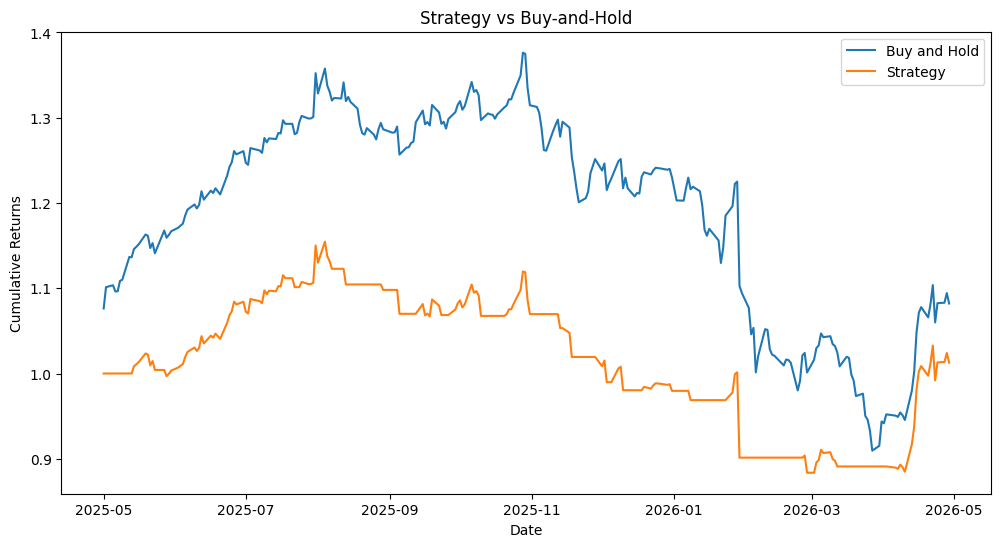

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    cumulative_market,
    label="Buy and Hold"
)

plt.plot(
    cumulative_strategy,
    label="Strategy"
)

plt.title("Strategy vs Buy-and-Hold")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.legend()

plt.show()

In [62]:
total_strategy_return = (
    cumulative_strategy.iloc[-1] - 1
)

total_market_return = (
    cumulative_market.iloc[-1] - 1
)

print(
    "Strategy Return:",
    round(total_strategy_return * 100, 2),
    "%"
)

print(
    "Market Return:",
    round(total_market_return * 100, 2),
    "%"
)

Strategy Return: 1.26 %
Market Return: 8.21 %


In [63]:
sharpe_ratio = (
    strategy_returns.mean()
    /
    strategy_returns.std()
) * (252 ** 0.5)

print(
    "Sharpe Ratio:",
    round(sharpe_ratio, 2)
)

Sharpe Ratio: 0.16


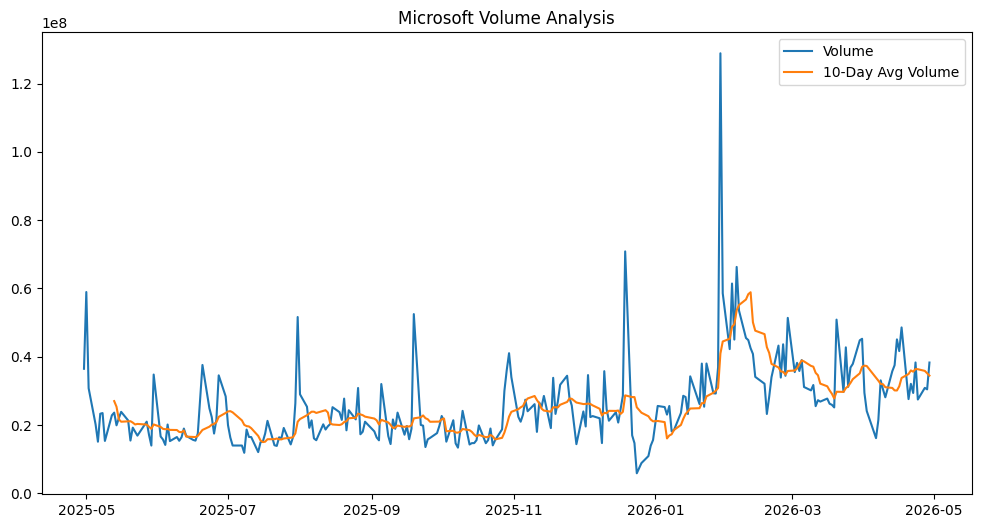

In [64]:
volume = data["Volume"]["MSFT"]

volume_ma = volume.rolling(window=10).mean()

plt.figure(figsize=(12,6))

plt.plot(
    volume.index,
    volume,
    label="Volume"
)

plt.plot(
    volume_ma.index,
    volume_ma,
    label="10-Day Avg Volume"
)

plt.title("Microsoft Volume Analysis")

plt.legend()

plt.show()